In [592]:
import pandas as pd
import importlib
import funciones as func #Tener funciones.py en mismo directorio. Tiene las funciones usadas para procesar un df
importlib.reload(func)
import numpy as np

In [593]:
data = pd.read_csv('../competition_data.csv')

In [594]:
import csv
f = open('../uri_to_duration.csv', 'r')
diccionario = {}
for line in csv.DictReader(f):
    diccionario[line['uri']] = float(line['duration'])
f.close()
diccionario

{'spotify:track:3jFfr89lnSmb4QBtfG8JBP': 187120.0,
 'spotify:track:09TTeexnlKewZdjOak2sV2': 292573.0,
 'spotify:track:0G3fbPbE1vGeABDEZF0jeG': 495400.0,
 'spotify:track:1NXvuBAq48QrxRFQZVmORQ': 430960.0,
 'spotify:track:2gYJY0sIx1ErgTIha2nPRg': 214848.0,
 'spotify:track:0njXuAkJVSpptzKniMBtIZ': 405499.0,
 'spotify:track:7Kszjzps0xbQXyo1pO4KfE': 331360.0,
 'spotify:track:39KmBOGkD1ztCbVeo2uspA': 277560.0,
 'spotify:track:0UAEHlFR79k9CJvknSGUNf': 215040.0,
 'spotify:track:1sWeSMifj6Z6kZyI6z3bRc': 171040.0,
 'spotify:track:0nLiqZ6A27jJri2VCalIUs': 388266.0,
 'spotify:track:1Ig4pCPanhzXl7C86MmBUc': 161133.0,
 'spotify:track:0WtDGnWL2KrMCk0mI1Gpwz': 326933.0,
 'spotify:track:326HJ8o8XJff8dSZOwe4GS': 288586.0,
 'spotify:track:1bSpwPhAxZwlR2enJJsv7U': 229120.0,
 'spotify:track:5luOvrlnzfvJQdQjrScVj4': 249500.0,
 'spotify:track:1SJtlNRJDeYHioymcvsqev': 216391.0,
 'spotify:track:06pjQCIybMiGrgtHODGa2m': 225906.0,
 'spotify:track:6eJlEcRmeyQfTlDQBDyqkW': 156680.0,
 'spotify:track:6A64S6NPQwA5KIQ

In [595]:
data = func.sort_by_ts(data)

In [596]:
# Toma aleatoriamente el 80 % de las filas
train = data.sample(frac=0.7, random_state=42).copy()

# El resto (20 %) lo podés obtener excluyendo esos índices
validation = data.drop(train.index).copy()

In [597]:
union = pd.concat([train, validation], axis=0)
union = func.procesar_df(union, diccionario)
train = func.procesar_df(train, diccionario)
validation = func.procesar_df_2(validation, diccionario)
validation_aux = validation.copy()

In [598]:
validation['TARGET'] = np.nan

In [599]:
validation = validation.merge(
    union[['Unnamed: 0', 'is_early_finish', 'racha_skips_prev']],
    on='Unnamed: 0',
    how='left'
)

In [600]:
# Establecer la columna identificadora como índice en ambos
validation.set_index('Unnamed: 0', inplace=True)
validation_aux.set_index('Unnamed: 0', inplace=True)

# Actualizar los valores faltantes de TARGET
validation['TARGET'].update(validation_aux['TARGET'])

# Si querés volver a tener la columna como normal:
validation.reset_index(inplace=True)

C:\Users\dafyd\AppData\Local\Temp\ipykernel_4100\504946687.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  validation['TARGET'].update(validation_aux['TARGET'])
C:\Users\dafyd\AppData\Local\Temp\ipykernel_4100\504946687.py:6: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ True  True  True ... False False False]' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  validation['TARGET'].update(validation_

In [603]:
validation = validation[train.columns]

In [604]:
import xgboost as xgb

drop_cols = [
    'Unnamed: 0','ts', 'platform', 'reason_start',
    'master_metadata_track_name',
    'master_metadata_album_artist_name',
    'master_metadata_album_album_name',
    'spotify_track_uri','platform', 'TARGET'
]
clf_xgb = xgb.XGBClassifier(objective = 'binary:logistic',
                            seed = 42,
                            eval_metric = 'auc',
                            early_stopping_rounds = 100,
                            learning_rate = 0.3,
                            gamma = 0.5,
                            reg_lambda=5)
clf_xgb.fit(train.drop(columns=drop_cols),
                train['TARGET'],
                eval_set=[(validation.drop(columns=drop_cols), validation['TARGET'])],
                verbose=True
                )

[0]	validation_0-auc:0.95842
[1]	validation_0-auc:0.96096
[2]	validation_0-auc:0.96151
[3]	validation_0-auc:0.96227
[4]	validation_0-auc:0.96284
[5]	validation_0-auc:0.96300
[6]	validation_0-auc:0.96336
[7]	validation_0-auc:0.96381
[8]	validation_0-auc:0.96417
[9]	validation_0-auc:0.96434
[10]	validation_0-auc:0.96465
[11]	validation_0-auc:0.96473
[12]	validation_0-auc:0.96502
[13]	validation_0-auc:0.96515
[14]	validation_0-auc:0.96514
[15]	validation_0-auc:0.96529
[16]	validation_0-auc:0.96531
[17]	validation_0-auc:0.96537
[18]	validation_0-auc:0.96579
[19]	validation_0-auc:0.96586
[20]	validation_0-auc:0.96594
[21]	validation_0-auc:0.96605
[22]	validation_0-auc:0.96605
[23]	validation_0-auc:0.96607
[24]	validation_0-auc:0.96617
[25]	validation_0-auc:0.96626
[26]	validation_0-auc:0.96626
[27]	validation_0-auc:0.96628
[28]	validation_0-auc:0.96631
[29]	validation_0-auc:0.96638
[30]	validation_0-auc:0.96641
[31]	validation_0-auc:0.96641
[32]	validation_0-auc:0.96653
[33]	validation_0-au

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=100,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=0.5, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.3, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

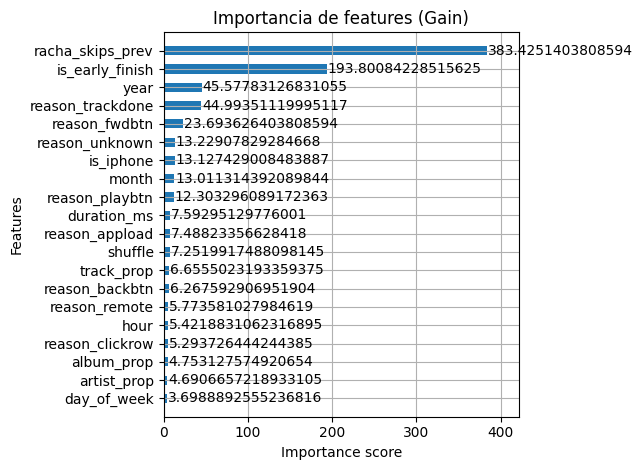

In [605]:
import matplotlib.pyplot as plt
xgb.plot_importance(clf_xgb, importance_type='gain', max_num_features=20, height=0.5)
plt.title("Importancia de features (Gain)")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import roc_auc_score

best = clf_xgb.best_iteration
print(best)

prediccion_val = clf_xgb.predict_proba(validation.drop(columns=drop_cols))[:, 1]
auc = roc_auc_score(validation['TARGET'].astype(int), prediccion_val)
print(f"AUC-ROC: {auc:.4f}")

75


ValueError: unknown format is not supported